## Variational Autoencoder for Prediction of X-ray reverberating response functions. 
Adopted from https://github.com/Jackson-Kang/Pytorch-VAE-tutorial/blob/master/01_Variational_AutoEncoder.ipynb

In [ ]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import scipy.signal as signal

from util import *

plt.rcParams['font.family'] = "Times New Roman"
plt.rcParams['font.size'] = 18

In [2]:
# DEVICE

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Device: mps


In [3]:
##############################################
# Important Flags
#data_flag = "random_a"
train_flag =        True
resume_training =   True
##############################################

## Data ReadOut

In [ ]:
# PATH to training data ~
PATH_TO_DATA = %TODO `Specify the path to the training data here`

LCs = sorted(glob.glob(PATH_TO_DATA+"/*.fits"))
LCs_filenames = [os.path.basename(x) for x in LCs]

# Extract Scale height for all data
h = np.array([float(s.split("_")[1][:-1])/10.0 for s in LCs_filenames])

# Provide the scale height condition for model training
h_min = 2.3
h_max = 20.

cond = np.intersect1d(np.where(h >=h_min), np.where(h <= h_max))
LCs = np.array(LCs)[cond]
LCs_filenames = np.array(LCs_filenames)[cond]

PATH_TO_GROUND_TRUTH = %TODO `Specify the path to the ground truth response functions here`
GTs = [PATH_TO_GROUND_TRUTH + "resp_"+"_".join(f.split(".")[0].split("_")[1:3])+".fits" for f in LCs_filenames]

In [ ]:
# Train-test split. we use 90% of the data for training and 10% for a test set.
train_test_ratio = 0.9
LC_train, LC_validate, Response_train, Response_validate = train_test_split(LCs, GTs, train_size=train_test_ratio, random_state=88)

# Use "Soft" for using soft X-ray light curves and "Hard" for using hard X-ray light curves.
mode = "Soft"
# mock_up flag is used to generate mock-up light curves with a given SNR and binning. If mock_up is set to False, the original light curves will be used.
mock_up = False
# noise mode can be "FullScaleNoise" or "PoissonNoise". "FullScaleNoise" adds Gaussian noise to the light curves, while "PoissonNoise" adds Poisson noise to the light curves.
noisemode = "FullScaleNoise"
# Signl-to-noise ratio (SNR)
snr = 1000.
# Signal binning in seconds. The light curves will be binned to this value before being used for training.
bin = 5.0

X_train = read_lightcurves(LC_train,mode=mode, mock_up=mock_up, snr=snr, bin=bin, noisemode=noisemode)
Y_train = read_response(Response_train,mode=mode)
X_validate = read_lightcurves(LC_validate,mode=mode, mock_up=mock_up, snr=snr, bin=bin, noisemode=noisemode)
Y_validate = read_response(Response_validate,mode=mode)

N_train, x_dim  = X_train.size()
_, y_dim = Y_train.size()

N_validate, _ = X_validate.size()
Taxis = read_fits_file(GTs[0])["time"].values

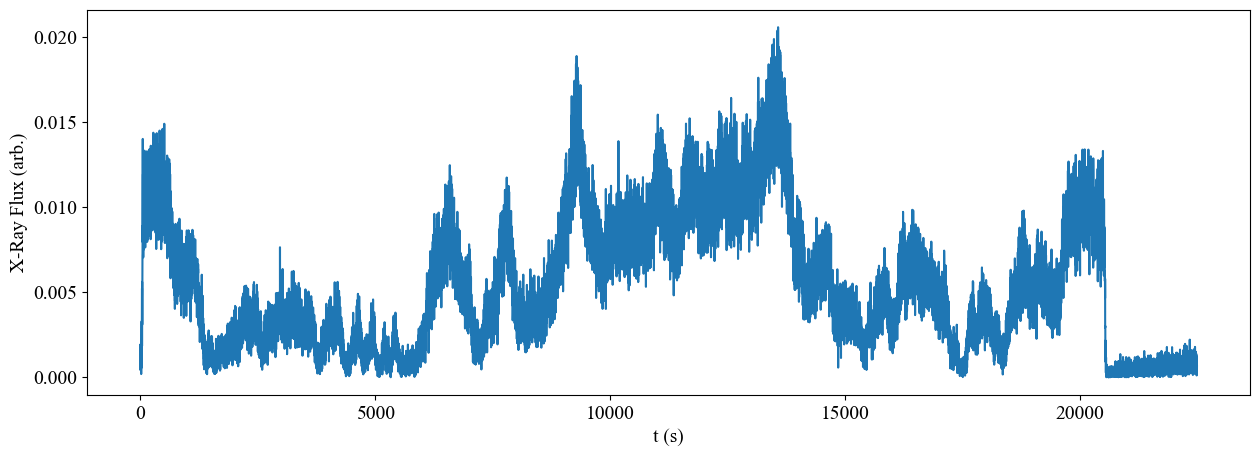

In [ ]:
# Here we plot the first light curve in the training set to visually inspect the data.
plt.figure(figsize=(15,5))
plt.plot(X_train[0].numpy())
plt.xlabel("t (s)")
plt.ylabel("X-Ray Flux (arb.)")
plt.show()

## Defining Network: Variational Autoencoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        '''
        Parameters:
        -----------
        input_dim: int
            The dimension of the input data.
        hidden_dim: int
            The dimension of the hidden layer.
        latent_dim: int
            The dimension of the latent space.
        '''
        super(Encoder, self).__init__()

        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_mean  = nn.Linear(hidden_dim, latent_dim)
        self.FC_var   = nn.Linear (hidden_dim, latent_dim)
        
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
        self.training = True
        
    def forward(self, x):
        '''
        Parameters:
        -----------
        x: torch.Tensor
            The input data.

        Returns:
        --------
        mean: torch.Tensor
            The mean of the latent variables.
        log_var: torch.Tensor
            The log of the variance of the latent variables.
        '''
        h_       = self.LeakyReLU(self.FC_input(x))
        h_       = self.LeakyReLU(self.FC_input2(h_))
        mean     = self.FC_mean(h_)
        log_var  = self.FC_var(h_)                     # encoder produces mean and log of variance 
                                                       #             (i.e., parateters of simple tractable normal distribution "q"
        
        return mean, log_var

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        '''
        Parameters:
        -----------
        latent_dim: int
            The dimension of the latent space.
        hidden_dim: int
            The dimension of the hidden layer.
        output_dim: int
            The dimension of the output data.
        '''
        super(Decoder, self).__init__()
        self.FC_hidden = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)
        
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        '''
        Parameters:
        -----------
        x: torch.Tensor
            The input data.

        Returns:
        --------
        x_hat: torch.Tensor
            The reconstructed data.
        '''
        h     = self.LeakyReLU(self.FC_hidden(x))
        h     = self.LeakyReLU(self.FC_hidden2(h))
        
        x_hat = torch.sigmoid(self.FC_output(h))
        return x_hat

In [ ]:
class Model(nn.Module):
    '''
    Variational Autoencoder (VAE) model that consists of an encoder and a decoder.
    '''
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
        
    def reparameterization(self, mean, var):
        '''
        Parameters:
        -----------
        mean: torch.Tensor
            The mean of the latent variables.
        var: torch.Tensor
            The variance of the latent variables.

        Returns:
        --------
        z: torch.Tensor
            The reparameterized latent variables.
        '''
        epsilon = torch.randn_like(var).to(DEVICE)        # sampling epsilon        
        z = mean + var*epsilon                          # reparameterization trick
        return z
                     
    def forward(self, x):
        '''
        Parameters:
        -----------
        x: torch.Tensor
            The input data.

        Returns:
        --------
        x_hat: torch.Tensor
            The reconstructed data.
        mean: torch.Tensor
            The mean of the latent variables.
        log_var: torch.Tensor
            The log of the variance of the latent variables.
        '''
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) # takes exponential function (log var -> var)
        x_hat            = self.Decoder(z)
        
        return x_hat, mean, log_var

In [ ]:
# Set the hyperparameters for the model

batch_size = 64     # Model will be trained with a batch size of 64. This means that the model will process 64 samples at a time before updating the weights.
hidden_dim = 400    # The hidden dimension of the encoder and decoder networks. This determines the number of neurons in the hidden layers of the networks.
latent_dim = 200    # The latent dimension of the encoder and decoder networks. This determines the number of neurons in the latent space.

lr = 1e-3           # The learning rate/Lagrange multiplier for the optimizer
epochs = 10000      # The number of epochs for training.


# Define the VAE model with the specified hyperparameters. The model is then moved to the specified device (CPU or GPU) for training.
encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim = hidden_dim, output_dim = y_dim)

model = Model(Encoder=encoder, Decoder=decoder)
model = model.to(DEVICE)

## Define Loss Function

In [ ]:
from torch.optim import Adam

BCE_loss = nn.BCELoss()

def loss_function(predicted, ground_truth, mean, log_var):
    '''
    Objective function for the VAE model. It combines the reconstruction loss (binary cross-entropy) and the Kullback-Leibler divergence (KLD) loss.
    Parameters:
    -----------
    predicted: torch.Tensor
        The predicted data.
    ground_truth: torch.Tensor
        The ground truth data.
    mean: torch.Tensor
        The mean of the latent variables.
    log_var: torch.Tensor
        The log of the variance of the latent variables.

    Returns:
    --------
    loss: torch.Tensor
        The total loss.
    '''
    reproduction_loss = nn.functional.binary_cross_entropy(ground_truth, predicted, reduction='sum')
    KLD      = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

optimizer = Adam(model.parameters(), lr=lr)         # Adaptive Moment Estimation (Adam) optimizer is used to update the model parameters during training.

## Training VAE

In [ ]:
def count_parameters(model):
    '''
    Count the number of trainable parameters in the model.
    Parameters:
    -----------
    model: torch.nn.Module
        The model for which to count parameters.

    Returns:
    --------
    int
        The number of trainable parameters.
    '''
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 13,564,000 trainable parameters


In [14]:
train_iterator = data.DataLoader(list(zip(X_train, Y_train)), batch_size=batch_size, shuffle=True)
validation_iterator = data.DataLoader(list(zip(X_validate, Y_validate)), batch_size=batch_size, shuffle=False)

In [ ]:
### Model name generation ###
# The model name is generated based on the training data path, mode, scale height range, learning rate, and other parameters such as mock-up flag, binning, noise mode, and SNR. This helps in keeping track of different model configurations during experiments.

tag1 = PATH_TO_DATA.split("_")[0]
tag2 = "_".join(PATH_TO_DATA.split("_")[-2:])
if tag1 == tag2:
     tag2 = ""
bin_tag = "nobin" if bin == False else f"{bin:.0f}binsize"
noise_tag = "" if snr in [None, False] else f"{10*np.round(snr/10) if snr>=10 else snr :.1e}snr"
poisson_tag = "Poisson" if noisemode is not None else ""


model_name = f"VAE_{tag1}_{mode}_{tag2}_{int(10*h_min):04}h_{int(10*h_max):04}h_{lr:.0e}lr"
if mock_up:
    model_name += "_mock_up"
if bin not in [False, 1., None]:
     model_name += f"_{bin_tag}"
if (snr not in [None, False]) and noisemode in ["GaussianNoise", "FullScaleNoise"]:
     model_name += f"_{noise_tag}Gaussian"
if poisson_tag:
    model_name += f"_{poisson_tag}"
if ((snr not in [None, False]) or noisemode == "PoissonNoise") and (bin not in [False, 1., None]):
     #model_name += "_binbeforeaddnoise"
     model_name += "_noisebeforebin"
    
print(f"Model name: {model_name}")

Model name: VAE_lc-data-extended-R_Soft__0023h_0200h_1e-03lr_5binsize_1.0e+03snrGaussian_Poisson_noisebeforebin


In [ ]:
### Training Block ###
# Set the starting epoch and initialize the loss history list. If training is resumed from a checkpoint, these values will be updated accordingly.
start_epoch = 0
loss_history = []

if train_flag:
    if resume_training and os.path.exists(f"Trained_Model/{model_name}.pt"):
        #model, optimizer, start_epoch, loss_history = load_model(f"{model_name}",model,optimizer)
        checkpoint = torch.load(f"Trained_Model/{model_name}.pt",weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        loss_history = checkpoint['loss']        
        print(f"Resuming training from epoch {start_epoch}")
    else:
        os.makedirs('Trained_Model/', exist_ok=True)
        print("Start training VAE...")
    
    model.train()
    for epoch in tqdm(range(start_epoch,epochs)):
        overall_loss = 0
        for batch_idx, (x, y) in enumerate(train_iterator):
            
            batch_size = x.size()[0]
            x = x.view(batch_size, x_dim)
            x = x.to(DEVICE)

            y = y.view(batch_size, y_dim)
            y = y.to(DEVICE)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(y, x_hat, mean, log_var)
            
            overall_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
        average_loss = overall_loss / (batch_idx*batch_size)
        loss_history.append(average_loss)
        
        if (epoch+1)%100.0 == 0:
            torch.save({
                'epoch': epoch +1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss_history,
                },
                f"Trained_Model/{model_name}.pt")

    print("Finish!!")

else:
    model, optimizer, start_epoch, loss_history = load_model(f"{model_name}",model,optimizer)      
    print(f"Load trained model...\n{model_name}")

Resuming training from epoch 10000


0it [00:00, ?it/s]

Finish!!


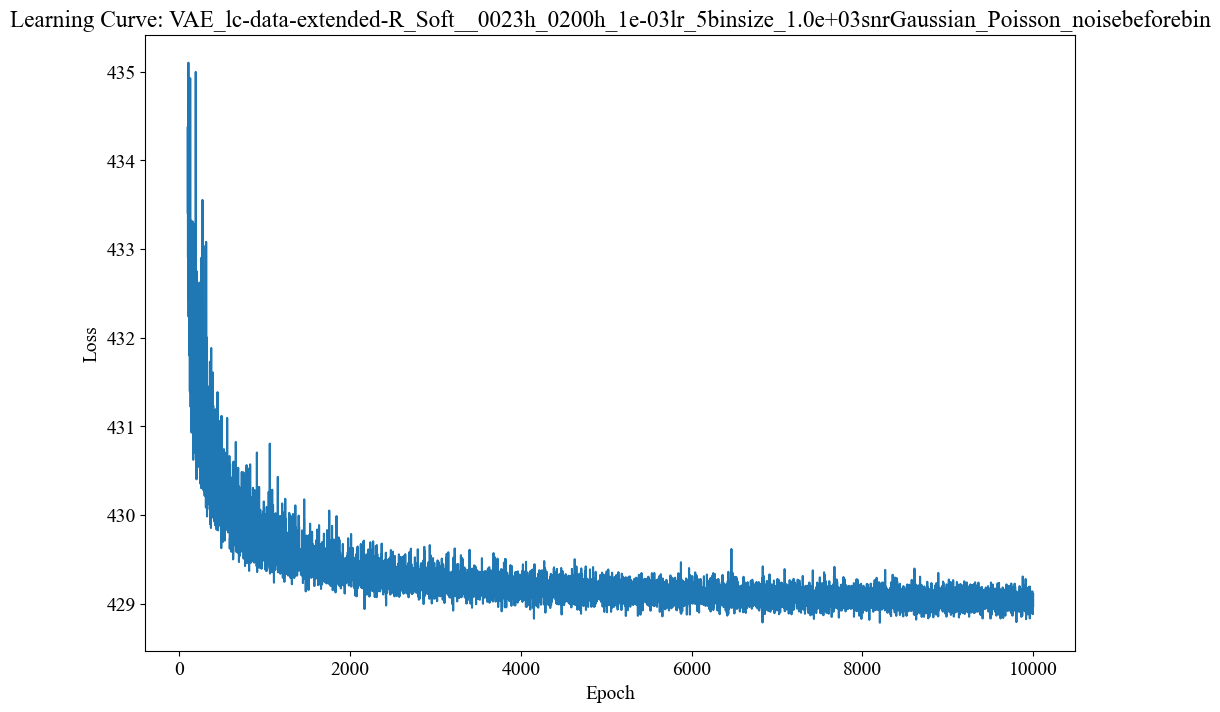

In [ ]:
### Visual Inspection of the learning curve ###
# Visually inspect the change of loss over epochs to ensure that the model is learning effectively. The learning curve can help identify issues such as overfitting or underfitting.

plt.figure(figsize=(12,8))
n_epoch = np.arange(len(loss_history))
cutoff = 100
plt.plot(n_epoch[cutoff::],loss_history[cutoff::])
plt.title(f"Learning Curve: {model_name}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
#plt.yscale('log')
plt.show()

## Testing VAE

In [ ]:
def get_predictions(model, iterator, device):
    '''
    Get predictions from the model for the given data iterator.
    Parameters:
    -----------
    model: torch.nn.Module
        The trained VAE model.
    iterator: torch.utils.data.DataLoader
        The data iterator for which to get predictions.
    device: torch.device
        The device on which to perform computations.
    Returns:
    --------
    lightcurves: torch.Tensor
        The input light curves.
    response: torch.Tensor
        The predicted responses.
    ground_truth: torch.Tensor
        The ground truth values.
    '''
    model.eval()
    
    lightcurves = []
    response = []
    ground_truth = []

    with torch.no_grad():

        for (x, y) in iterator:

            x = x.to(device)

            y_pred, _ ,_ = model(x)

            lightcurves.append(x.cpu())
            response.append(y_pred.cpu())
            ground_truth.append(y.cpu())

    lightcurves = torch.cat(lightcurves, dim=0)
    response = torch.cat(response, dim=0)
    ground_truth = torch.cat(ground_truth, dim=0)

    return lightcurves, response, ground_truth

In [ ]:
Indicators = {"Cross-Correlation":extract_cc_amplitude,
              "Signal Coherence":get_coherence
              }

In [21]:
lightcurves_train, response_regen_train, ground_truth_train = get_predictions(model, train_iterator, DEVICE)
metric_train = compute_similarity(ground_truth_train, response_regen_train, Indicators)

    Cross-Correlation between predicted and true response functions is: 0.982 (+ 0.013 - 0.042)
    Signal Coherence between predicted and true response functions is: 0.961 (+ 0.036 - 0.213)


In [22]:
lightcurves_val, response_regen_val, ground_truth_val = get_predictions(model, validation_iterator, DEVICE)
metric_val = compute_similarity(ground_truth_val, response_regen_val, Indicators)

    Cross-Correlation between predicted and true response functions is: 0.980 (+ 0.014 - 0.040)
    Signal Coherence between predicted and true response functions is: 0.952 (+ 0.041 - 0.221)


In [ ]:
cc_amplitude = metric_val["Cross-Correlation"]
coh = metric_val["Signal Coherence"]

mask = np.where(coh>=0.7)
response_regen_val = response_regen_val[mask]
ground_truth_val = ground_truth_val[mask]

In [29]:
Mean_Metric = {"Train":{},"Test":{}}
Std_Metric = {"Train":{},"Test":{}}
for label in Mean_Metric.keys():
    if label == "Train":
        for key in metric_train.keys():
            Mean_Metric[label][key] = np.mean(metric_train[key])
            Std_Metric[label][key] = np.std(metric_train[key])
    if label == "Test":
        for key in metric_val.keys():
            Mean_Metric[label][key] = np.mean(metric_val[key])
            Std_Metric[label][key] = np.std(metric_val[key])
    

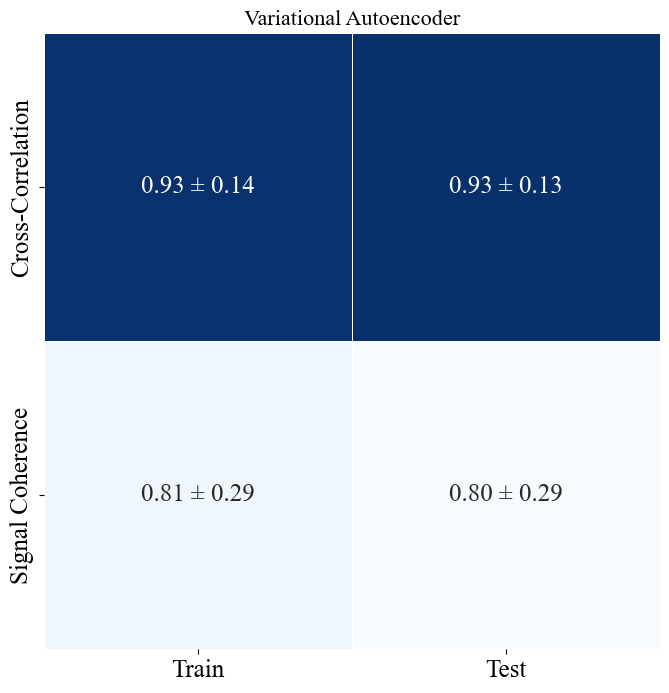

In [30]:
import seaborn as sns

df_m = pd.DataFrame(Mean_Metric)
df_s = pd.DataFrame(Std_Metric)

annot_train = [f"{df_m.iloc[j]['Train']:.2f} ± {df_s.iloc[j]['Train']:.2f}" for j in range(df_m.shape[0])]
annot_test = [f"{df_m.iloc[j]['Test']:.2f} ± {df_s.iloc[j]['Test']:.2f}" for j in range(df_m.shape[0])]
annot = np.array([annot_train, annot_test]).T

plt.figure(figsize=(15,8))
ax = sns.heatmap(df_m, annot=annot, cmap="Blues", cbar= False, linewidths=.5, fmt="", square=True)
plt.title("Variational Autoencoder", fontsize=16)
plt.show()

### Report Generator

In [32]:
if not os.path.exists(f"Report/"):
    os.makedirs("Report/")

report = {
    "snr" : snr,
    "learning_rate": lr,
    "loss": loss_history,
    "n_iter" : len(loss_history),
    "cross_correlation_train": metric_train['Cross-Correlation'].tolist(),
    "cross_correlation_test": metric_val['Cross-Correlation'].tolist(),
    "signal_coherance_train": metric_train['Signal Coherence'].tolist(),
    "signal_coherance_test": metric_val['Signal Coherence'].tolist()
}

import json
with open(f'Report/{model_name}.json', "w") as outfile:
    json.dump(report, outfile)

### Test on Another Test Set

In [ ]:
# We Test with Another test set which varying Photon Index, Inclination and Black Hole mass

Folder = %TODO `Specify the path to the other testset here`
Scenarios = %TODO      `Available scenarios which could be simulated, e.g. varyPhotonIndex, varyPhotonIndex+Inclination, varyPhotonIndex+Inclination+M, and varyRF`
PATH_TO_TESTSET_2  = Folder + Scenarios

Files = sorted(glob.glob(f'{PATH_TO_TESTSET_2}/*.fits'))
record_name = ["_".join(f.split('/')[-1].split("_")[:-1]) for f in Files]

X_test2 = read_lightcurves(Files, mode="Soft", snr=snr, noisemode=noisemode, bin=bin)

In [ ]:
PATH_TO_GROUND_TRUTH = "ResponseFunction2/"
Response_test2 = [PATH_TO_GROUND_TRUTH + "resp_0100h_45i.fits" for _ in range(len(Files))]
Y_test2 = read_response(Response_test2, mode="Soft")

In [36]:
test2_iterator = data.DataLoader(list(zip(X_test2, Y_test2)), batch_size=batch_size, shuffle=False)
lightcurves_test, response_regen_test, ground_truth_test = get_predictions(model, test2_iterator, DEVICE)
metric_test2 = compute_similarity(ground_truth_test, response_regen_test, Indicators)

    Cross-Correlation between predicted and true response functions is: 0.758 (+ 0.116 - 0.074)
    Signal Coherence between predicted and true response functions is: 0.968 (+ 0.004 - 0.137)


## Deploy on Real Data

In [ ]:
Folder = %TODO `Specify the path to the real light curves here`

# You may specify the energy range of the light curves to be used for testing. For example, "*300_1000eV*" will select light curves in the 0.3 - 1.0 keV range (soft X-ray).
Files = sorted(glob.glob(f'{Folder}/*300_1000eV*.fits'))     
record_name = [f.split("/")[-1].split("_")[0] for f in Files]


def read_real_lightcurves(f, bin=False, interpolate=True):
    '''
    Read real light curves from a file and return the time and flux values as PyTorch tensors
    Parameters:
    -----------
    f: str
        The path to the light curve file. The file can be in CSV, FITS, or JSON format.
    bin: float, optional
        The bin size for the light curve. If specified, the light curve will be binned to this size. Default is False (no binning).
    interpolate: bool, optional
        Whether to interpolate the light curve to fill in missing values. Default is True, which will use Piecewise Cubic Hermite Interpolating Polynomial (PCHIP) interpolation. If set to False, missing values will be dropped.
    Returns:
    --------
    T_obs: torch.Tensor
        The time values of the light curve.
    X_obs: torch.Tensor
        The flux values of the light curve.
    '''
    if f.split(".")[-1] == 'csv':
        df = pd.read_csv(f)
    if f.split(".")[-1] == 'fits':
        fits_file = fits.open(f)
        df = Table(fits_file[1].data).to_pandas()
        df["TIME"] -= df["TIME"][0]    
    if f.split(".")[-1] == 'json':
        df = pd.read_json(f)
    
    if bin not in [False, None ,1., 1]:
        if type(float(bin)) in [float, int]:        
            df = binning(df,bin_size=float(bin))
            T_obs = df["time"].values
        else:
            raise ValueError("Bin Size must be specified!")
    if interpolate:
        df = df.interpolate(method='pchip', axis=0)    
        df = df.dropna(axis = 0, how='any')

    try:
        T_obs = df["TIME"].values
    except:
        pass

    T_obs = torch.tensor(T_obs, dtype=torch.float32)
    try:
        X_obs = df["RATE"].values
    except:
        X_obs = df["FLUX"].values
        
    X_obs = torch.tensor(X_obs, dtype=torch.float32)
    return T_obs, X_obs

In [42]:
Time = Taxis
model.eval()
response = []
output_tag = "_".join(model_name.split("_")[:3])
if ((snr not in [None, False]) and noisemode in ["GaussianNoise","FullScaleNoise"]):
     snr_tag = f"{snr:.1e}" 
elif noisemode=="PoissonNoise":
     snr_tag = "PoissonNoise"
else:
     snr_tag = "NoiseFree"

PATH_out = f"{tag1}_{tag2}_Response_Function_IRAS_13223/{output_tag}_{int(10*h_min):04}h_{int(10*h_max):04}h/PCHIP_Interpolated/{snr_tag}/"
if not os.path.exists(PATH_out):
     os.makedirs(PATH_out)
print(PATH_out)     
with torch.no_grad():
     
     for f in Files:
          try:
               _, x = read_real_lightcurves(f,bin=bin)
               x = x[:x_dim]
               x = x.unsqueeze(0)
               x = x.to(DEVICE)
               y_pred, _ ,_ = model(x)
               y_pred = y_pred.cpu().detach().numpy()[0]
               response.append(y_pred)
               record_name = f.split("/")[-1].split(".")[0].split("-")[-1]

               resp = pd.DataFrame([Time, y_pred])
               resp = resp.T
               resp.columns = ["Time","Response"]
               resp.to_csv(f"{PATH_out}/response_"+record_name+".csv",index=False)
          except:
              pass

lc-data-extended-R__Response_Function_IRAS_13223/VAE_lc-data-extended-R_Soft_0023h_0200h/PCHIP_Interpolated/1.0e+03/
